# Name : Muhammad Danish Zaheer Awan
# REG id : 25280092
## Task 4 - Open-Set Recognition

## Imports and project setup

In [1]:
# Import standard utilities for cleanup, paths, tables, plotting, and PyTorch.
# Locate the PA_1 root so imports work when this notebook starts inside task4/scripts.

import gc
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

In [2]:
project_root = Path.cwd().resolve()
while project_root.name != 'PA_1' and project_root.parent != project_root:
    project_root = project_root.parent
if project_root.name != 'PA_1':
    raise FileNotFoundError('Run this notebook from inside the PA_1 project.')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [3]:
# Import configuration, data-download, and known-only training helpers.
# The CIFAR-100 helper downloads files only; it does not reveal images or labels.

from task4.configs.config_loader import (
    create_output_directories,
    get_output_paths,
    load_config,
)
from task4.data.cifar10 import prepare_cifar10_datasets
from task4.data.download_cifar100 import download_cifar100_files
from task4.training.train import (
    select_training_device,
    set_random_seed,
    train_or_load_task4_method,
)

In [4]:
# Import known-data calibration, experiment locking, and final evaluation functions.
# Importing the evaluator is safe because CIFAR-100 is imported only inside its final function.

from task4.evaluation.evaluate_osr import (
    create_experiment_lock,
    prepare_known_evaluation,
    run_final_open_set_evaluation,
)
from task4.evaluation.metrics import save_json

## Runtime and exact configurations

In [5]:
# Define reproducible random state and automatically select the available CUDA GPU.
# The training code also restores this seed independently for each method.

def configure_runtime(seed=6304):
    set_random_seed(seed)
    return select_training_device()

In [6]:
# Initialize the shared runtime and show whether GPU acceleration is active.
# CUDA is used for training and feature extraction whenever it is available.

DEVICE = configure_runtime()
print(f'Project root: {project_root}')
print(f'PyTorch version: {torch.__version__}')
print(f'Selected device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(DEVICE)}')

Project root: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1
PyTorch version: 2.11.0+cu128
Selected device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [7]:
# Define one helper that loads the validated Vanilla, GCSC, RPL, and PROSER YAML files.
# The loader rejects changes to the fixed architecture and optimization protocol.

def load_task4_configurations():
    return {name: load_config(name) for name in ('vanilla', 'gcsc', 'rpl', 'proser')}

In [8]:
# Load all exact configurations and create the data-cache and result directories.
# The same output layout is shared by every method, without placeholder .gitkeep files.

CONFIGURATIONS = load_task4_configurations()
OUTPUT_PATHS = create_output_directories(CONFIGURATIONS['vanilla'])
configuration_rows = []
for method_name, configuration in CONFIGURATIONS.items():
    configuration_rows.append({
        'method': method_name,
        'epochs': configuration['training']['maximum_epochs'],
        'learning_rate': configuration['training']['learning_rate'],
        'randaugment': configuration['method']['use_randaugment'],
        'dummy_classes': configuration['method']['number_of_dummy_classes'],
        'reciprocal_points': configuration['method'].get('number_of_reciprocal_points', 0),
    })
display(pd.DataFrame(configuration_rows))

,method,epochs,learning_rate,randaugment,dummy_classes,reciprocal_points
0,vanilla,100,0.100,False,0,0
1,gcsc,100,0.100,True,0,0
2,rpl,100,0.100,False,0,1
3,proser,50,0.001,False,5,0


## CIFAR-10 data and fixed 90/10 split

In [9]:
# Define data preparation separately because each method has its own training transform.
# Validation, test, and Mahalanobis-training views remain deterministic and unaugmented.

def prepare_method_datasets(configuration):
    return prepare_cifar10_datasets(configuration)

In [10]:
# Download CIFAR-10 and construct its train, validation, and test datasets.
# The saved split is reused so every Task 4 method sees the same examples.

VANILLA_DATASETS, CIFAR10_PROTOCOL = prepare_method_datasets(
    CONFIGURATIONS['vanilla']
)
print(f"Split file: {OUTPUT_PATHS['cifar10_split_file']}")
print(f"Split seed: {CIFAR10_PROTOCOL['seed']}")

c:\Users\DanishZaheer\anaconda3\envs\ATML\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Using the existing CIFAR-10 split.
Split file: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\data\splits\cifar10_seed6304.json
Split seed: 6304


In [11]:
# Download and verify only the CIFAR-100 archive files before training starts.
# Its images and labels are not constructed until the locked final evaluation.

CIFAR100_DIRECTORY = download_cifar100_files(
    OUTPUT_PATHS['cifar100_directory'],
    download=CONFIGURATIONS['vanilla']['dataset']['download'],
)
print(f"CIFAR-100 files: {CIFAR100_DIRECTORY}")

CIFAR-100 files already available: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\Data\cifar100
CIFAR-100 files: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\Data\cifar100


In [12]:
# Define a compact size table for the optimization, validation, and test views.
# The train_evaluation view reuses training indices without stochastic augmentation.

def create_dataset_size_table(datasets):
    return pd.DataFrame([
        {'split': split_name, 'examples': len(dataset)}
        for split_name, dataset in datasets.items()
    ])

In [13]:
# Display dataset sizes before any optimization starts.
# Expected counts are 45,000 train, 5,000 validation, and 10,000 test examples.

display(create_dataset_size_table(VANILLA_DATASETS))

,split,examples
0,train,45000
1,train_evaluation,45000
2,validation,5000
3,test,10000


## Train or reuse selected checkpoints

In [14]:
# Define a method runner that prepares the correct transform and trains or reuses a checkpoint.
# Keep only compact checkpoint metadata after each run so GPU memory is free for the next method.

def run_training_method(method_name, datasets=None, force_retrain=False):
    configuration = CONFIGURATIONS[method_name]
    if datasets is None:
        datasets, protocol = prepare_method_datasets(configuration)
    else:
        protocol = CIFAR10_PROTOCOL
    result = train_or_load_task4_method(
        configuration,
        datasets,
        device=DEVICE,
        force_retrain=force_retrain,
    )
    checkpoint_keys = ('epoch', 'validation', 'selection_metric', 'cifar100_used_during_training')
    result['checkpoint'] = {key: result['checkpoint'][key] for key in checkpoint_keys}
    result['model'].to('cpu')
    del result['model']
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result, protocol

In [15]:
# Choose whether existing exact checkpoints should be replaced by fresh training runs.
# Keep False for safe notebook restarts; set True only when intentionally retraining all methods.

FORCE_RETRAIN = False
TRAINING_RESULTS = {}

### 1 Vanilla

In [16]:
# Train Vanilla first because its selected checkpoint initializes the later PROSER model.
# Selection uses CIFAR-10 validation accuracy only and writes one history CSV per epoch.

TRAINING_RESULTS['vanilla'], _ = run_training_method(
    'vanilla',
    datasets=VANILLA_DATASETS,
    force_retrain=FORCE_RETRAIN,
)
print(TRAINING_RESULTS['vanilla']['checkpoint_file'])

CIFAR ResNet-18 parameters: 11,173,962/11,173,962 trainable
Loaded Task 4 checkpoint: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\results\checkpoints\vanilla_best.pt
C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\results\checkpoints\vanilla_best.pt


### 2 GCSC

In [17]:
# Train GCSC with the same protocol while adding RandAugment(2, 9) to training images.
# Its initialization, optimizer, schedule, split, and checkpoint rule match Vanilla.

TRAINING_RESULTS['gcsc'], _ = run_training_method(
    'gcsc',
    force_retrain=FORCE_RETRAIN,
)
print(TRAINING_RESULTS['gcsc']['checkpoint_file'])

c:\Users\DanishZaheer\anaconda3\envs\ATML\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Using the existing CIFAR-10 split.
CIFAR ResNet-18 parameters: 11,173,962/11,173,962 trainable
Loaded Task 4 checkpoint: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\results\checkpoints\gcsc_best.pt
C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\results\checkpoints\gcsc_best.pt


### 3 PROSER

In [18]:
# Fine-tune PROSER from the selected Vanilla checkpoint with five dummy classifiers.
# Classifier placeholders and different-class layer2 mixup use equal batch halves.

TRAINING_RESULTS['proser'], _ = run_training_method(
    'proser',
    force_retrain=FORCE_RETRAIN,
)
print(TRAINING_RESULTS['proser']['checkpoint_file'])

Using the existing CIFAR-10 split.
CIFAR ResNet-18 parameters: 11,176,527/11,176,527 trainable
Loaded Task 4 checkpoint: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\results\checkpoints\proser_best.pt
C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\results\checkpoints\proser_best.pt


### 4 RPL

In [19]:
# Train RPL from random initialization using reciprocal-distance classification.
# Its open-space term learns bounded class margins without using CIFAR-100 examples.

TRAINING_RESULTS['rpl'], _ = run_training_method(
    'rpl',
    force_retrain=FORCE_RETRAIN,
)
print(TRAINING_RESULTS['rpl']['checkpoint_file'])

Using the existing CIFAR-10 split.
CIFAR ResNet-18 parameters: 11,173,962/11,173,962 trainable
Loaded Task 4 checkpoint: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\results\checkpoints\rpl_best.pt
C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\results\checkpoints\rpl_best.pt


## Training histories and selected epochs

In [20]:
# Define one comparison plot for loss and CIFAR-10 validation accuracy.
# Curves are read from the returned histories and saved under task4/results/figures.

def plot_training_histories(training_results, output_file):
    figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for method_name, result in training_results.items():
        history = result['history']
        if history.empty:
            continue
        axes[0].plot(history['epoch'], history['total_loss'], label=method_name.upper())
        axes[1].plot(history['epoch'], history['validation_accuracy'], label=method_name.upper())
    axes[0].set(title='Training loss', xlabel='Epoch', ylabel='Loss')
    axes[1].set(title='CIFAR-10 validation accuracy', xlabel='Epoch', ylabel='Accuracy')
    for axis in axes:
        axis.grid(alpha=0.25)
        axis.legend()
    figure.tight_layout()
    output_file.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(output_file, dpi=200, bbox_inches='tight')
    plt.show()
    return output_file

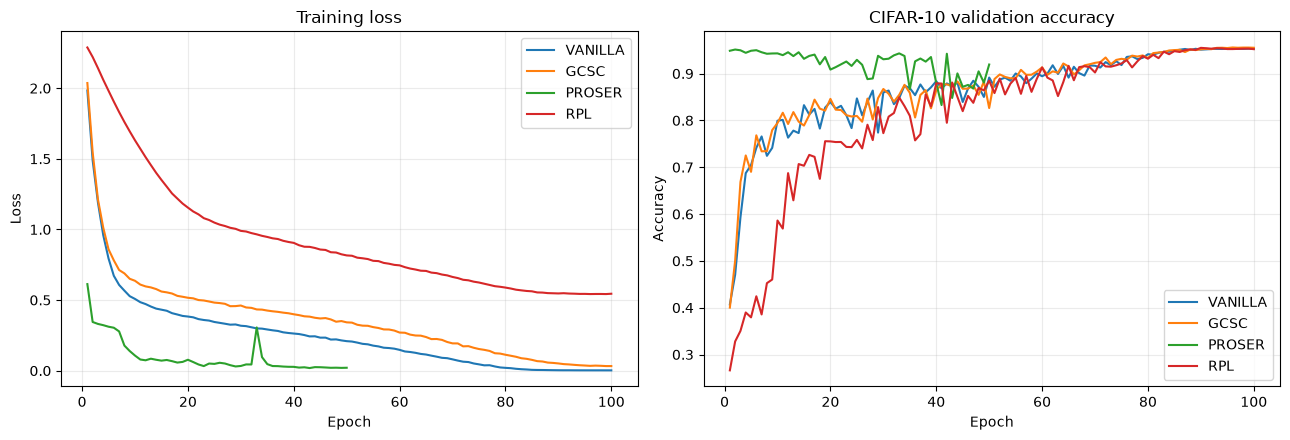

C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\results\figures\task4_training_histories.png


In [21]:
# Plot the three completed histories and save the reproducible figure.
# Missing histories are skipped so old checkpoints can still be inspected safely.

TRAINING_FIGURE = plot_training_histories(
    TRAINING_RESULTS,
    OUTPUT_PATHS['figures_directory'] / 'task4_training_histories.png',
)
print(TRAINING_FIGURE)

In [22]:
# Define a table showing the source-selected epoch and validation metrics per checkpoint.
# This evidence confirms that CIFAR-100 did not participate in model selection.

def create_checkpoint_selection_table(training_results):
    rows = []
    for method_name, result in training_results.items():
        checkpoint = result['checkpoint']
        rows.append({
            'method': method_name,
            'selected_epoch': checkpoint['epoch'],
            'validation_accuracy': checkpoint['validation']['accuracy'],
            'validation_macro_f1': checkpoint['validation']['macro_f1'],
            'cifar100_used_during_training': checkpoint['cifar100_used_during_training'],
        })
    return pd.DataFrame(rows)

In [23]:
# Display checkpoint-selection evidence after all three known-only runs finish.
# Every row must show False in the final column before calibration continues.

CHECKPOINT_TABLE = create_checkpoint_selection_table(TRAINING_RESULTS)
display(CHECKPOINT_TABLE)

,method,selected_epoch,validation_accuracy,validation_macro_f1,cifar100_used_during_training
0,vanilla,99,0.9532,0.953271,False
1,gcsc,96,0.9558,0.955903,False
2,proser,2,0.9514,0.951485,False
3,rpl,90,0.9550,0.955062,False


## Freeze CIFAR-10 outputs, scores, and thresholds

In [24]:
# Define preparation of deterministic known-only views for all four methods.
# Method-specific optimization transforms are irrelevant to these unaugmented evaluation views.

def prepare_known_dataset_mapping():
    datasets_by_method = {'vanilla': VANILLA_DATASETS}
    for method_name in ('gcsc', 'rpl', 'proser'):
        datasets, protocol = prepare_method_datasets(CONFIGURATIONS[method_name])
        if protocol != CIFAR10_PROTOCOL:
            raise ValueError('All methods must reuse the exact CIFAR-10 split.')
        datasets_by_method[method_name] = datasets
    return datasets_by_method

In [25]:
# Build known-only dataset mappings and extract frozen checkpoint outputs.
# This cell fits Vanilla Mahalanobis statistics and calibrates every threshold on validation.

KNOWN_DATASETS = prepare_known_dataset_mapping()
KNOWN_EVALUATION = prepare_known_evaluation(
    CONFIGURATIONS,
    KNOWN_DATASETS,
    device=DEVICE,
)

c:\Users\DanishZaheer\anaconda3\envs\ATML\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Using the existing CIFAR-10 split.
Using the existing CIFAR-10 split.
Using the existing CIFAR-10 split.
CIFAR ResNet-18 parameters: 11,173,962/11,173,962 trainable
Cached known outputs for vanilla: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\results\checkpoints\vanilla_best.pt
CIFAR ResNet-18 parameters: 11,173,962/11,173,962 trainable
Cached known outputs for gcsc: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\results\checkpoints\gcsc_best.pt
CIFAR ResNet-18 parameters: 11,173,962/11,173,962 trainable
Cached known outputs for rpl: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\results\checkpoints\rpl_best.pt
CIFAR ResNet-18 parameters: 11,176,527/11,176,527 trainable
Cached known outputs for proser: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\results\checkpoints\proser_best.pt


In [26]:
# Display closed-set CIFAR-10 test accuracy and macro-F1 for the selected models.
# These test metrics do not affect checkpoints, score definitions, or thresholds.

display(KNOWN_EVALUATION['closed_set_table'])

,model,cifar10_test_accuracy,cifar10_test_macro_f1
0,vanilla,0.9497,0.949676
1,gcsc,0.9510,0.950957
2,rpl,0.9460,0.945990
3,proser,0.9444,0.944354


In [27]:
# Define a readable table from the validation-only threshold registry.
# All scores are unknownness values, so examples are accepted when score is at most tau.

def create_threshold_table(threshold_registry):
    return pd.DataFrame([
        {'result_name': name, **record}
        for name, record in threshold_registry.items()
    ])

In [28]:
# Display every threshold before writing hypotheses or revealing CIFAR-100.
# Each tau is the 95th percentile of the corresponding CIFAR-10 validation score.

THRESHOLD_TABLE = create_threshold_table(KNOWN_EVALUATION['thresholds'])
display(THRESHOLD_TABLE)

,result_name,model,score,threshold,validation_percentile,number_of_validation_examples,dummy_calibration_bias
0,vanilla_msp,vanilla,msp,1.538313e-01,95.0,5000,NaN
1,vanilla_mls,vanilla,mls,-5.869001e+00,95.0,5000,NaN
2,vanilla_energy,vanilla,energy,-6.065875e+00,95.0,5000,NaN
3,vanilla_mahalanobis,vanilla,mahalanobis,2.906798e+03,95.0,5000,NaN
4,gcsc_mls,gcsc,mls,-6.123928e+00,95.0,5000,NaN
5,rpl_mls,rpl,mls,-7.221279e+00,95.0,5000,NaN
6,rpl_msp,rpl,msp,4.879738e-01,95.0,5000,NaN
7,proser_mls,proser,mls,-4.130692e+00,95.0,5000,NaN
8,proser_placeholder,proser,placeholder,2.214798e-12,95.0,5000,-0.550738


## Write hypotheses before seeing unknown results


In [29]:
# Record predictions about score and method comparisons before final unknown evaluation.
# Replace all TODO text; these statements are hashed into the immutable experiment lock.

HYPOTHESES = {
    'best_vanilla_score': 'I expect MLS to give the best overall Vanilla unknown AUROC because an unknown image may still produce a high relative softmax probability, while its maximum raw logit should remain lower than for familiar CIFAR-10 images.',
    'near_versus_far': 'I expect near unknowns to be harder to reject than far unknowns because their semantic and visual features are closer to the CIFAR-10 classes.',
    'gcsc_effect': 'I expect GCSC augmentation to slightly improve closed-set accuracy by learning more robust features, but its MLS open-set improvement may be small because stronger augmentation can also broaden the region treated as known.',
    'rpl_effect': 'I expect RPL to improve unknown rejection by explicitly learning reciprocal points and an open-space margin, although this extra constraint may cause a small decrease in closed-set accuracy.',
    'proser_effect': 'I expect the PROSER placeholder score to reject unknowns better than PROSER MLS because the dummy classifiers are trained to represent unsupported regions, while its known-class accuracy should remain close to Vanilla.',
    'expected_failure_pattern': 'I expect most confidently accepted unknowns to come from the near group, especially vehicles being predicted as automobile or truck and animals being predicted as cat, dog, deer, or horse. Far failures may occur when an object has a familiar texture, color, or background.',
}
HYPOTHESES_FILE = OUTPUT_PATHS['metrics_directory'] / 'task4_hypotheses.json'
save_json(HYPOTHESES, HYPOTHESES_FILE)
print(HYPOTHESES_FILE)

C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\results\metrics\task4_hypotheses.json


## Lock all decisions

In [30]:
# Create paths for the immutable lock and inspect the artifacts it will protect.
# The lock includes configs, checkpoints, known caches, thresholds, score code, and hypotheses.

LOCK_FILE = OUTPUT_PATHS['metrics_directory'] / 'task4_experiment_lock.json'
print(f'Hypotheses: {HYPOTHESES_FILE}')
print(f'Lock: {LOCK_FILE}')

Hypotheses: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\results\metrics\task4_hypotheses.json
Lock: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\results\metrics\task4_experiment_lock.json


In [31]:
# Freeze all decisions only after replacing every TODO hypothesis above.
# Any later artifact change invalidates the lock and blocks CIFAR-100 evaluation.

EXPERIMENT_LOCK = create_experiment_lock(CONFIGURATIONS, LOCK_FILE)
print('Task 4 decisions are locked.')

Locked Task 4 decisions: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\results\metrics\task4_experiment_lock.json
Task 4 decisions are locked.


## One guarded final CIFAR-100 evaluation

In [32]:
# Keep final unknown evaluation disabled until all known-only choices are frozen.
# Changing this flag is the explicit confirmation that no further tuning will follow.

RUN_FINAL_UNKNOWN_EVALUATION = True

In [33]:
# Validate the immutable lock and construct the CIFAR-100 near/far evaluation views.
# Pre-downloaded unknown images and labels are revealed only inside this enabled call.

if not RUN_FINAL_UNKNOWN_EVALUATION:
    raise RuntimeError('Set RUN_FINAL_UNKNOWN_EVALUATION=True only for the final run.')
FINAL_RESULTS = run_final_open_set_evaluation(
    CONFIGURATIONS,
    LOCK_FILE,
    device=DEVICE,
)

c:\Users\DanishZaheer\anaconda3\envs\ATML\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


CIFAR ResNet-18 parameters: 11,173,962/11,173,962 trainable
Evaluated locked model: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\results\checkpoints\vanilla_best.pt
CIFAR ResNet-18 parameters: 11,173,962/11,173,962 trainable
Evaluated locked model: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\results\checkpoints\gcsc_best.pt
CIFAR ResNet-18 parameters: 11,173,962/11,173,962 trainable
Evaluated locked model: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\results\checkpoints\rpl_best.pt
CIFAR ResNet-18 parameters: 11,176,527/11,176,527 trainable
Evaluated locked model: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\results\checkpoints\proser_best.pt


## Required result tables and evidence

In [34]:
# Display the required comparison of MSP, MLS, Energy, and Mahalanobis on Vanilla.
# It reports known CSA plus near, far, and combined open-set measurements.

display(FINAL_RESULTS['vanilla_score_table'])

,result_name,model,score,cifar10_test_accuracy,cifar10_test_macro_f1,known_vs_near_auroc,known_vs_far_auroc,known_vs_all_unknown_auroc,threshold,known_test_acceptance_rate,near_unknown_rejection_rate,far_unknown_rejection_rate,all_unknown_rejection_rate,near_fpr_at_95_tpr,far_fpr_at_95_tpr,all_unknown_fpr_at_95_tpr
0,vanilla_msp,vanilla,msp,0.9497,0.949676,0.827924,0.890130,0.859027,0.153831,0.9491,0.29250,0.41875,0.355625,0.70750,0.58125,0.644375
1,vanilla_mls,vanilla,mls,0.9497,0.949676,0.815499,0.882805,0.849152,-5.869001,0.9527,0.32375,0.50375,0.413750,0.67625,0.49625,0.586250
2,vanilla_energy,vanilla,energy,0.9497,0.949676,0.815642,0.883139,0.849390,-6.065875,0.9533,0.32125,0.51125,0.416250,0.67875,0.48875,0.583750
3,vanilla_mahalanobis,vanilla,mahalanobis,0.9497,0.949676,0.797054,0.917107,0.857081,2906.797670,0.9513,0.27625,0.49625,0.386250,0.72375,0.50375,0.613750


In [35]:
# Display trained-model MLS plus the RPL-MSP and PROSER-placeholder scores.
# This table contains Vanilla, GCSC, RPL, and PROSER result rows.

display(FINAL_RESULTS['model_comparison_table'])

,result_name,model,score,cifar10_test_accuracy,cifar10_test_macro_f1,known_vs_near_auroc,known_vs_far_auroc,known_vs_all_unknown_auroc,threshold,known_test_acceptance_rate,near_unknown_rejection_rate,far_unknown_rejection_rate,all_unknown_rejection_rate,near_fpr_at_95_tpr,far_fpr_at_95_tpr,all_unknown_fpr_at_95_tpr
0,vanilla_mls,vanilla,mls,0.9497,0.949676,0.815499,0.882805,0.849152,-5.869001e+00,0.9527,0.32375,0.50375,0.413750,0.67625,0.49625,0.586250
1,gcsc_mls,gcsc,mls,0.9510,0.950957,0.815171,0.907143,0.861157,-6.123928e+00,0.9531,0.32625,0.53750,0.431875,0.67375,0.46250,0.568125
2,rpl_mls,rpl,mls,0.9460,0.945990,0.636304,0.622992,0.629648,-7.221279e+00,0.9442,0.27125,0.37125,0.321250,0.72875,0.62875,0.678750
3,rpl_msp,rpl,msp,0.9460,0.945990,0.725226,0.829659,0.777442,4.879738e-01,0.9434,0.31250,0.47625,0.394375,0.68750,0.52375,0.605625
4,proser_mls,proser,mls,0.9444,0.944354,0.837727,0.882233,0.859980,-4.130692e+00,0.9536,0.33375,0.44250,0.388125,0.66625,0.55750,0.611875
5,proser_placeholder,proser,placeholder,0.9444,0.944354,0.817220,0.890739,0.853979,2.214798e-12,0.9569,0.29000,0.44375,0.366875,0.71000,0.55625,0.633125


In [36]:
# Display incorrectly accepted near and far unknown examples under Vanilla MLS tau.
# Each row records unknown class, predicted known class, score, threshold, and image index.

display(FINAL_RESULTS['failure_table'])

,identifier,dataset_index,unknown_group,unknown_class,predicted_known_index,unknownness_score,threshold,predicted_known_class
0,cifar100_test_00720,720,near,wolf,5,-12.147110,-5.869001,dog
1,cifar100_test_04586,4586,near,bus,1,-11.810209,-5.869001,automobile
2,cifar100_test_09231,9231,near,wolf,3,-11.766224,-5.869001,cat
3,cifar100_test_06297,6297,far,keyboard,2,-13.337425,-5.869001,bird
4,cifar100_test_05219,5219,far,mushroom,3,-12.022891,-5.869001,cat
5,cifar100_test_07443,7443,far,bottle,3,-12.021277,-5.869001,cat


In [37]:
# List the saved tables, predictions, and figures for direct use in the report.
# Large logits and features stay under Data/task4_cache instead of the result folder.

for output_name, output_path in {
    'Vanilla score table': OUTPUT_PATHS['metrics_directory'] / 'vanilla_score_comparison.csv',
    'Model table': OUTPUT_PATHS['metrics_directory'] / 'trained_model_comparison.csv',
    'Failure table': OUTPUT_PATHS['predictions_directory'] / 'vanilla_mls_accepted_failures.csv',
    'Score distributions': OUTPUT_PATHS['figures_directory'] / 'vanilla_score_distributions.png',
    'Failure images': OUTPUT_PATHS['figures_directory'] / 'vanilla_mls_accepted_failures.png',
}.items():
    print(f'{output_name}: {output_path}')

Vanilla score table: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\results\metrics\vanilla_score_comparison.csv
Model table: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\results\metrics\trained_model_comparison.csv
Failure table: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\results\predictions\vanilla_mls_accepted_failures.csv
Score distributions: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\results\figures\vanilla_score_distributions.png
Failure images: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task4\results\figures\vanilla_mls_accepted_failures.png
